# Potencial electrostático en una sección rectangular

**Autores:** Bryan Alejandro Berbesi - 2210701, Santiago Correa Vergara - 2182212,

Camila Valentina Castillo - 2221748, Samuel González Martínez - 2240680

---

**Resumen**

En este trabajo se aborda de manera rigurosa la solución de la ecuación de Laplace para el potencial electrostático en una región rectangular sometida a condiciones de frontera mixtas. En primer lugar, se desarrolla analíticamente el método de separación de variables paso a paso, aplicando las condiciones de contorno y la propiedad de ortogonalidad de las funciones de Fourier para obtener la solución general exacta en forma de serie infinita. Posteriormente, se explica cómo esta solución general permite modelar y graficar el comportamiento físico del sistema para el caso particular asignado al grupo, tomando \(a=2\), \(b=1\) y \(V_1=8\), de acuerdo con las instrucciones del profesor. Finalmente, se introduce la formulación numérica mediante el método de diferencias finitas, detallando su fundamentación matemática y analizando las librerías de Python idóneas para su implementación computacional, con el fin de validar los resultados analíticos frente a los discretos.

---

## 1. Planteamiento del problema

El problema físico consiste en determinar el potencial electrostático $\varphi(x,y)$ en el interior de una región bidimensional rectangular libre de cargas (densidad de carga nula, $\rho = 0$). El rectángulo está definido en el dominio $0 \leq x \leq a$ y $0 \leq y \leq b$.

De acuerdo con los parámetros asignados para este grupo, se toman los valores:

$$
a=2,
\qquad
b=1,
\qquad
V_1=8
$$

donde el valor de $V_1$ corresponde al mayor último dígito de los códigos estudiantiles de los integrantes del grupo. En este caso, dicho valor es 8, correspondiente al código de Camila Valentina Castillo (2221748).

Por las leyes del electromagnetismo, al no existir carga encerrada, el potencial debe satisfacer la **ecuación de Laplace** en dos dimensiones:

$$
\nabla^2 \varphi =
\frac{\partial^2 \varphi}{\partial x^2}
+
\frac{\partial^2 \varphi}{\partial y^2}
=0
$$

Las paredes del rectángulo están sujetas a condiciones de frontera de Dirichlet (potencial especificado en los bordes). Tres de las paredes están conectadas a tierra, lo que implica un potencial nulo, mientras que la pared izquierda se mantiene a un potencial constante $V_1$. Matemáticamente, las condiciones de frontera se definen como:

1. **Frontera inferior:** $\varphi(x,0)=0$

2. **Frontera superior:** $\varphi(x,b)=0$

3. **Frontera derecha:** $\varphi(a,y)=0$

4. **Frontera izquierda:** $\varphi(0,y)=8$

El objetivo es encontrar una función $\varphi(x,y)$ que satisfaga la ecuación diferencial parcial y, simultáneamente, cumpla con estas cuatro condiciones de frontera para el dominio rectangular definido por $a=2$ y $b=1$.



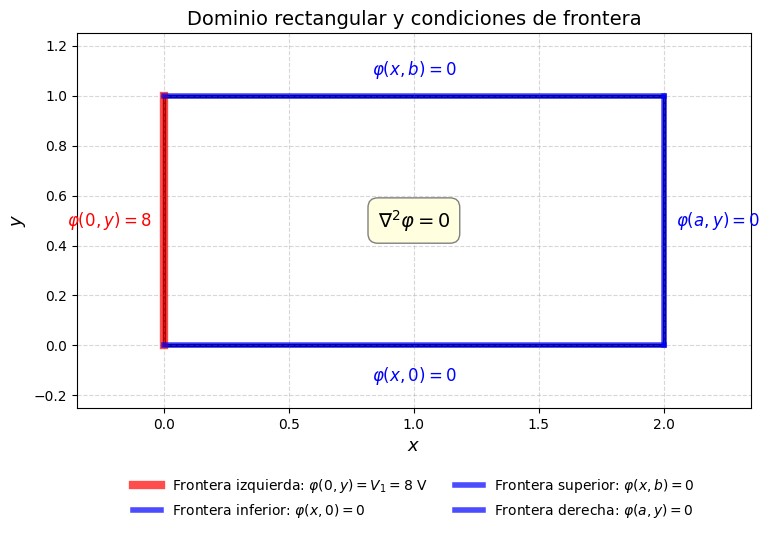

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros asignados
a, b = 2.0, 1.0
V1 = 8.0

# Crear figura y ejes
fig, ax = plt.subplots(figsize=(8, 5))

# Dibujar el rectángulo
rect = plt.Rectangle((0, 0), a, b, fill=False, linewidth=2.5, edgecolor='black')
ax.add_patch(rect)

# Colores y marcadores de las condiciones de frontera
# Lado izquierdo: V1 (rojo)
ax.plot([0, 0], [0, b], 'r-', linewidth=6, alpha=0.7,
        label=rf'Frontera izquierda: $\varphi(0,y) = V_1 = {V1:.0f}$ V')

# Lados a tierra (azul)
ax.plot([0, a], [0, 0], 'b-', linewidth=4, alpha=0.7,
        label=r'Frontera inferior: $\varphi(x,0) = 0$')
ax.plot([0, a], [b, b], 'b-', linewidth=4, alpha=0.7,
        label=r'Frontera superior: $\varphi(x,b) = 0$')
ax.plot([a, a], [0, b], 'b-', linewidth=4, alpha=0.7,
        label=r'Frontera derecha: $\varphi(a,y) = 0$')

# Texto de condiciones de frontera
ax.text(-0.05, b/2, rf'$\varphi(0,y) = {V1:.0f}$', ha='right', va='center',
        fontsize=12, color='red')
ax.text(a/2, -0.08, r'$\varphi(x,0) = 0$', ha='center', va='top',
        fontsize=12, color='blue')
ax.text(a/2, b + 0.06, r'$\varphi(x,b) = 0$', ha='center', va='bottom',
        fontsize=12, color='blue')
ax.text(a + 0.05, b/2, r'$\varphi(a,y) = 0$', ha='left', va='center',
        fontsize=12, color='blue')

# Indicar la región interior con la Ecuación de Laplace
ax.text(a/2, b/2, r'$\nabla^2 \varphi = 0$', ha='center', va='center',
        fontsize=14, style='italic',
        bbox=dict(facecolor='lightyellow', edgecolor='gray', boxstyle='round,pad=0.5'))

# Configuración de ejes ajustada al nuevo aspecto (2x1)
ax.set_xlim(-0.35, a + 0.35)
ax.set_ylim(-0.25, b + 0.25)
ax.set_xlabel(r'$x$', fontsize=13)
ax.set_ylabel(r'$y$', fontsize=13)
ax.set_title('Dominio rectangular y condiciones de frontera', fontsize=14)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)

# Leyenda bajo el gráfico
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

## 2. Desarrollo analítico paso a paso (Separación de variables)

Para resolver analíticamente este problema, se asume que la solución puede expresarse como el producto de dos funciones independientes: una que depende solo de $x$ y otra que depende solo de $y$:

$$ \varphi(x,y) = X(x)Y(y) $$

Sustituyendo esta propuesta en la ecuación de Laplace:

$$ X''(x)Y(y) + X(x)Y''(y) = 0 $$

Dividiendo toda la expresión entre $X(x)Y(y)$, se separan las variables a cada lado de la igualdad:

$$ \frac{X''(x)}{X(x)} = -\frac{Y''(y)}{Y(y)} $$

Dado que el lado izquierdo depende exclusivamente de $x$ y el lado derecho exclusivamente de $y$, la única forma de que esta igualdad se cumpla para cualquier valor de $x$ y $y$ es que ambos lados sean iguales a una constante de separación. La elección del signo de esta constante es crucial. Observando las condiciones de frontera en $y$ (bordes superior e inferior con valor cero), se necesitan funciones oscilatorias (senos/cosenos) en la dirección $y$ para poder anularse dos veces. Por lo tanto, se iguala a una constante positiva $k^2$:

$$ \frac{X''}{X} = k^2 \quad \text{y} \quad -\frac{Y''}{Y} = k^2 $$

Esto genera dos ecuaciones diferenciales ordinarias (EDO):

1. $X''(x) - k^2 X(x) = 0$
2. $Y''(y) + k^2 Y(y) = 0$

### Paso 2.1: Solución para la dirección $y$

La ecuación para $Y$ describe un oscilador armónico. Su solución general es:

$$ Y(y) = C \cos(ky) + D \sin(ky) $$

Aplicando las condiciones de frontera homogéneas en $y$:

- Condición en $y=0$: $\varphi(x,0) = X(x)Y(0) = 0 \Rightarrow Y(0) = 0$.
  $$ Y(0) = C \cos(0) + D \sin(0) = C = 0 $$
  Por tanto, $Y(y) = D \sin(ky)$.

- Condición en $y=b$: $\varphi(x,b) = X(x)Y(b) = 0 \Rightarrow Y(b) = 0$.
  $$ Y(b) = D \sin(kb) = 0 $$
  Para evitar la solución trivial ($D=0$), se exige que $\sin(kb) = 0$. Esto ocurre cuando el argumento es un múltiplo entero de $\pi$:
  $$ kb = n\pi \implies k_n = \frac{n\pi}{b}, \quad \text{para } n = 1, 2, 3, \dots $$

Se han hallado los autovalores $k_n$ y las autofunciones correspondientes:

$$ Y_n(y) = \sin\left(\frac{n\pi y}{b}\right) $$

*(La constante $D$ se absorberá más adelante en una constante general).*

### Paso 2.2: Solución para la dirección $x$

Se toma la ecuación de $X$ con los valores de $k_n$ encontrados:

$$ X''(x) - k_n^2 X(x) = 0 $$

Las soluciones para esta EDO son exponenciales reales, que pueden escribirse equivalentemente en términos de senos y cosenos hiperbólicos. Como se tiene una condición de frontera en $x=a$ donde el potencial es nulo ($\varphi(a,y) = 0$), es estratégicamente conveniente escribir la solución desplazada hacia $a$:

$$ X_n(x) = A_n \sinh(k_n(a-x)) + B_n \cosh(k_n(a-x)) $$

Aplicando la condición en $x=a$:

$$ X_n(a) = A_n \sinh(0) + B_n \cosh(0) = B_n = 0 $$

Por lo tanto, la solución para $X$ queda reducida a:

$$ X_n(x) = A_n \sinh\left(\frac{n\pi(a-x)}{b}\right) $$

---

## 3. Obtención de la solución general analítica

Por el principio de superposición (dado que la ecuación de Laplace es lineal), la solución general es la suma de todos los modos posibles (todas las combinaciones de $n$):

$$ \varphi(x,y) = \sum_{n=1}^{\infty} A_n \sinh\left(\frac{n\pi (a-x)}{b}\right) \sin\left(\frac{n\pi y}{b}\right) $$

### Cálculo de los coeficientes $A_n$

Aún falta aplicar la condición no homogénea en $x=0$, donde el potencial es $V_1$:

$$ \varphi(0,y) = V_1 = \sum_{n=1}^{\infty} A_n \sinh\left(\frac{n\pi a}{b}\right) \sin\left(\frac{n\pi y}{b}\right) $$

Esta igualdad es una **serie de Fourier de senos**. Para aislar el coeficiente $A_n$, se multiplican ambos lados de la ecuación por $\sin\left(\frac{m\pi y}{b}\right)$ y se integra respecto a $y$ desde $0$ hasta $b$:

$$ \int_0^b V_1 \sin\left(\frac{m\pi y}{b}\right) dy = \sum_{n=1}^{\infty} A_n \sinh\left(\frac{n\pi a}{b}\right) \int_0^b \sin\left(\frac{n\pi y}{b}\right) \sin\left(\frac{m\pi y}{b}\right) dy $$

Por el **teorema de ortogonalidad**, la integral de la derecha es nula para todo $n \neq m$, y vale $\frac{b}{2}$ cuando $n = m$. Esto colapsa la sumatoria infinita a un solo término:

$$ V_1 \int_0^b \sin\left(\frac{n\pi y}{b}\right) dy = A_n \sinh\left(\frac{n\pi a}{b}\right) \frac{b}{2} $$

Resolviendo la integral del lado izquierdo:

$$ \int_0^b \sin\left(\frac{n\pi y}{b}\right) dy = \left[ -\frac{b}{n\pi} \cos\left(\frac{n\pi y}{b}\right) \right]_0^b = -\frac{b}{n\pi} (\cos(n\pi) - 1) = \frac{b}{n\pi} (1 - (-1)^n) $$

Igualando y despejando $A_n$:

$$ V_1 \frac{b}{n\pi} (1 - (-1)^n) = A_n \sinh\left(\frac{n\pi a}{b}\right) \frac{b}{2} $$

$$ A_n = \frac{2V_1}{n\pi \sinh\left(\frac{n\pi a}{b}\right)} (1 - (-1)^n) $$

El término $(1 - (-1)^n)$ vale $0$ si $n$ es par, y vale $2$ si $n$ es impar. Por ende:

$$ A_n = \frac{4V_1}{n\pi \sinh\left(\frac{n\pi a}{b}\right)} \quad \text{para } n = 1, 3, 5, \dots $$

Sustituyendo esto en la superposición, se obtiene la **solución analítica general exacta**:

$$ \varphi(x,y) = \sum_{n=1,3,5\dots}^{\infty} \frac{4V_1}{n\pi \sinh\left(\dfrac{n\pi a}{b}\right)} \sinh\left(\frac{n\pi (a-x)}{b}\right) \sin\left(\frac{n\pi y}{b}\right) $$

---

## 4. Graficación a partir de la Solución General Analítica

Es de vital importancia aclarar que **para graficar el comportamiento físico del sistema NO se utiliza la simple ecuación de separación de variables $\varphi = X(x)Y(y)$ de un solo modo $n$**.

Un solo término de la serie satisface la ecuación de Laplace y las condiciones homogéneas (los bordes a tierra), pero **fracasa totalmente** en cumplir la condición del borde izquierdo ($V_1$ constante). Para que la frontera en $x=0$ sea un potencial plano y continuo $V_1$, la matemática exige que las infinitas ondas senoidales se sumen (superposición).

Por lo tanto, **la ecuación que se introduce en el software para generar las gráficas es la Solución General (la sumatoria infinita).** Como computacionalmente es imposible sumar infinitos términos, se utiliza una suma truncada (por ejemplo, los primeros $N=50$ o $N=100$ términos impares). Cuantos más términos se incluyan, más precisa será la representación geométrica, especialmente cerca de las esquinas en $x=0$ donde ocurre una discontinuidad abrupta (fenómeno de Gibbs).

---

## 5. Formulación del Método Numérico: Diferencias Finitas

Para contrastar la validez de la solución analítica, se implementa una solución numérica mediante el **Método de Diferencias Finitas**.

Este método no busca una función matemática continua, sino que discretiza el dominio rectangular en una "malla" o cuadrícula de puntos separada por distancias $\Delta x$ y $\Delta y$. El objetivo es encontrar el valor del potencial exclusivamente en esos puntos de la malla.

### Fundamentación (Series de Taylor)

Si se toma un punto coordenado $(x_i, y_j)$ y se denota el potencial allí como $\varphi_{i,j}$, se pueden aproximar las segundas derivadas usando la expansión en serie de Taylor hacia adelante y hacia atrás. Al sumar ambas series, se cancelan las derivadas impares y se despeja la segunda derivada central:

$$ \frac{\partial^2 \varphi}{\partial x^2} \approx \frac{\varphi_{i+1,j} - 2\varphi_{i,j} + \varphi_{i-1,j}}{\Delta x^2} $$

$$ \frac{\partial^2 \varphi}{\partial y^2} \approx \frac{\varphi_{i,j+1} - 2\varphi_{i,j} + \varphi_{i,j-1}}{\Delta y^2} $$

Reemplazando estas aproximaciones en la ecuación de Laplace continua ($\nabla^2 \varphi = 0$), se obtiene la **Ecuación de Laplace Discreta** (conocida como el esquema de 5 puntos):

$$ \frac{\varphi_{i+1,j} - 2\varphi_{i,j} + \varphi_{i-1,j}}{\Delta x^2} + \frac{\varphi_{i,j+1} - 2\varphi_{i,j} + \varphi_{i,j-1}}{\Delta y^2} = 0 $$

Si se supone por simplicidad que $\Delta x = \Delta y$ (malla cuadrada), la ecuación se simplifica notablemente, indicando que el potencial en un nodo es exactamente el promedio de sus cuatro vecinos ortogonales:

$$ \varphi_{i,j} = \frac{1}{4} \left( \varphi_{i+1,j} + \varphi_{i-1,j} + \varphi_{i,j+1} + \varphi_{i,j-1} \right) $$

Esta ecuación se aplica a *cada nodo interior* del rectángulo. Los nodos de los bordes no son incógnitas, pues sus valores están dictados por las condiciones de frontera ($V_1$ a la izquierda, $0$ en el resto). El resultado es un sistema de ecuaciones lineales de la forma $A\boldsymbol{\varphi} = \mathbf{b}$, donde $A$ es una matriz gigante pero rala (llena de ceros), $\boldsymbol{\varphi}$ es el vector columna con todos los potenciales interiores a calcular, y $\mathbf{b}$ es un vector que contiene la influencia de los bordes.

---

## 6. Librerías de Python para solución de Ecuaciones Diferenciales

El ensamblaje y la solución del sistema lineal $A\boldsymbol{\varphi} = \mathbf{b}$ requiere herramientas computacionales especializadas, debido a que, para mallas finas, la matriz $A$ puede tener millones de entradas. En Python existen diferentes librerías según el método numérico a emplear:

1. **`scipy.sparse` (elegida para Diferencias Finitas):**
   - **Cómo funciona:** Permite crear matrices dispersas (sparse). En lugar de guardar millones de ceros en la memoria RAM, `scipy.sparse` solo guarda las coordenadas de los números distintos de cero.
   - **Resolución:** Utiliza algoritmos como `spsolve` (directo) o métodos iterativos (`cg`, `gmres`) integrados, lo que permite resolver sistemas enormes en fracciones de segundo. Es ideal para geometrías rectangulares simples como la de este problema, sin depender de software pesado.

2. **`FEniCS` / `dolfinx` (Método de Elementos Finitos - FEM):**
   - Opera bajo la "formulación débil" o variacional de la PDE. Requiere definir un espacio de funciones de prueba. Es excepcionalmente potente para geometrías irregulares (por ejemplo, formas curvas o agujeros), ya que usa mallas triangulares no estructuradas, pero su curva de aprendizaje es alta.

3. **`FiPy` (Volúmenes Finitos):**
   - Desarrollada por el NIST, se basa en la conservación de flujos a través de las celdas de la malla. Es excelente para problemas de difusión y transporte en ingeniería de materiales.

4. **`scikit-fem`:**
   - Una alternativa a FEniCS puramente en Python. No requiere compiladores complejos de C++ en segundo plano. Es ideal para aprender elementos finitos y realizar prototipos rápidos.

Para nuestro caso particular (geometría rectangular), la combinación nativa de **NumPy + SciPy.sparse** es la ruta óptima: ofrece la máxima eficiencia sin la complejidad de generar mallas triangulares.

---

## 7. Algoritmo en pseudocódigo

A continuación se presenta un algoritmo resumido de 8 pasos que integra el cálculo de la solución analítica, la solución numérica por diferencias finitas y la generación de las gráficas. Este algoritmo representa el flujo de trabajo completo implementado en Python.

> ### ⚙️ Algoritmo: Solución completa del problema de Laplace
>
> **Entrada:** $a$, $b$, $V_1$, $N$ (número de términos impares), $n_x$, $n_y$  
> **Salida:** Gráficas del potencial analítico y numérico
>
> 1. Definir los parámetros geométricos y físicos: $a$, $b$, $V_1$, $N$, $n_x$, $n_y$.
> 2. Crear la malla de puntos $(X, Y)$ en el dominio $[0,a]\times[0,b]$ usando `meshgrid`.
> 3. Calcular la solución analítica $\varphi_{\text{analítica}}$ mediante la serie truncada de Fourier:
>    $$\varphi_{\text{analítica}} = \sum_{\substack{n=1 \\ n \text{ impar}}}^{2N-1} \frac{4V_1}{n\pi \sinh\left(\frac{n\pi a}{b}\right)} \sinh\left(\frac{n\pi(a-X)}{b}\right) \sin\left(\frac{n\pi Y}{b}\right)$$
> 4. Definir los espaciamientos de la malla: $\Delta x = a/(n_x-1)$, $\Delta y = b/(n_y-1)$.
> 5. Construir las matrices tridiagonales $T_x$ y $T_y$ de segunda derivada y las matrices identidad $I_x$, $I_y$.
> 6. Ensamblar la matriz dispersa del laplaciano discreto $L = I_y \otimes T_x + T_y \otimes I_x$ y el vector $\mathbf{b}$ con las contribuciones de frontera.
> 7. Resolver el sistema lineal $L\,\boldsymbol{\varphi}_{\text{numérica}} = \mathbf{b}$ usando `scipy.sparse.linalg.spsolve`.
> 8. Graficar y comparar la solución analítica y la solución numérica (superficie, contorno y/o perfil 1D).

Este algoritmo condensa en un solo flujo la implementación completa, desde el cálculo analítico hasta la generación de las figuras finales.

---

## 8. Gráficas y Análisis de Resultados

Antes de calcular las soluciones, se definen los parámetros geométricos y físicos del problema. Se usará un rectángulo de $2 \times 1$ metro, un potencial $V_1 = 8$ V en la frontera izquierda, y una malla de $50 \times 50$ puntos.

**Gráfica 1: Solución Analítica (Serie de Fourier truncada)**

> **Análisis:** En esta figura se observa el mapa de calor (distribución del potencial) de la solución general obtenida por separación de variables, usando los primeros 50 términos impares de la serie. Se evidencia claramente cómo el potencial toma el valor máximo $V_1$ en $x=0$ y decae de manera continua a medida que se avanza en $x$, llegando a $0$ en $x=a$. Los bordes superior e inferior ($y=0$, $y=b$) fuerzan a las líneas equipotenciales a curvarse hacia cero. Cerca de las esquinas izquierdas (donde se cruzan el potencial $V_1$ y el potencial $0$), el gradiente de color es muy abrupto, lo cual es propio del modelo matemático puro debido a la discontinuidad en los bordes.

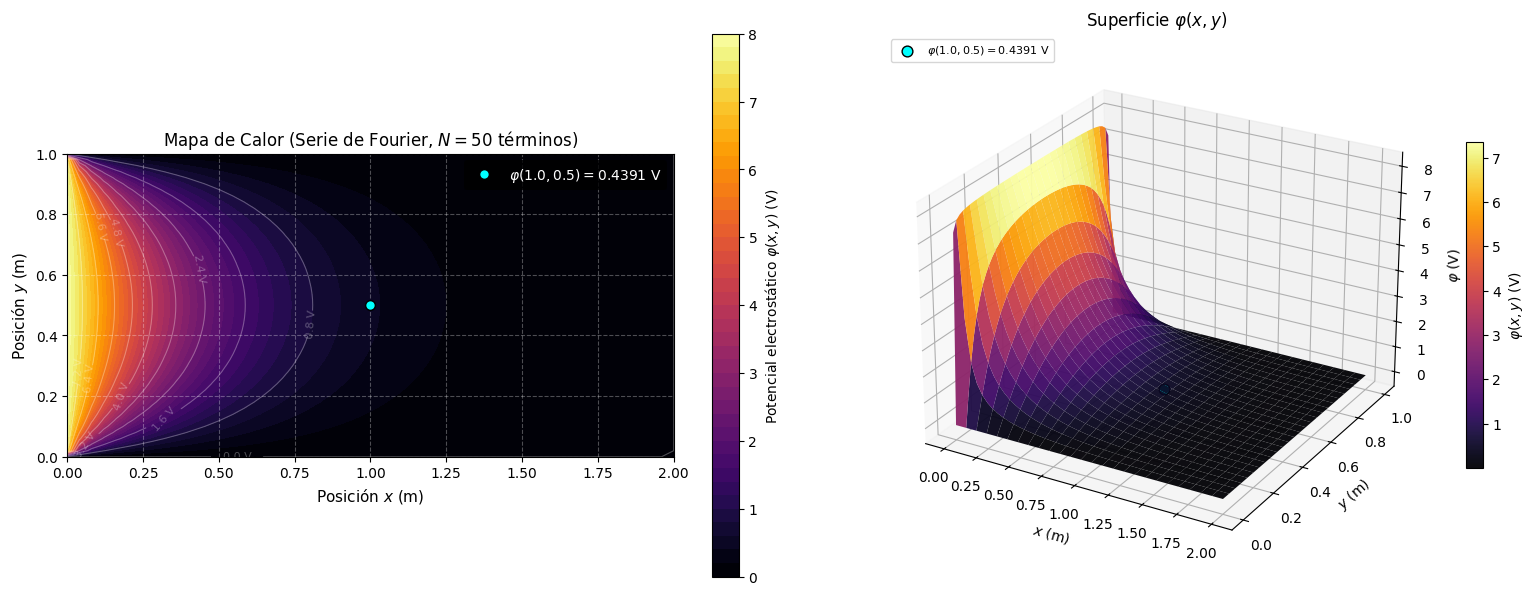

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Necesario para gráficos 3D

# PARÁMETROS DEL PROBLEMA
a, b = 2.0, 1.0      # Dimensiones del rectángulo (2 x 1 m)
V1 = 8.0             # Potencial en la frontera izquierda (x=0)
Nx, Ny = 51, 51      # Número de puntos en la malla para la graficación

# Creación de la malla bidimensional (Grid)
x = np.linspace(0, a, Nx)
y = np.linspace(0, b, Ny)
X, Y = np.meshgrid(x, y)

# 1. SOLUCIÓN ANALÍTICA (Serie de Fourier truncada)
phi_analitica = np.zeros_like(X)
N_terminos = 50  # Número de términos impares para truncar la serie infinita

for n in range(1, 2 * N_terminos, 2):
    An = (4 * V1) / (n * np.pi * np.sinh(n * np.pi * a / b))
    Xx = np.sinh(n * np.pi * (a - X) / b)
    Yy = np.sin(n * np.pi * Y / b)
    phi_analitica += An * Xx * Yy

# CÁLCULO DEL POTENCIAL EN EL PUNTO (1.0, 0.5)
idx_x_punto = np.argmin(np.abs(x - 1.0))
idx_y_punto = np.argmin(np.abs(y - 0.5))
x_p, y_p = x[idx_x_punto], y[idx_y_punto]
phi_punto = phi_analitica[idx_y_punto, idx_x_punto]

# 2. GRAFICACIÓN: FIGURA CON DOS SUBPLOTS (contorno + superficie 3D)
fig = plt.figure(figsize=(16, 6))

# --- SUBPLOT 1: Mapa de calor (contourf) ---
ax1 = fig.add_subplot(1, 2, 1)

contour = ax1.contourf(X, Y, phi_analitica, levels=50, cmap='inferno')
cbar = fig.colorbar(contour, ax=ax1, label=r'Potencial electrostático $\varphi(x,y)$ (V)')

lines = ax1.contour(X, Y, phi_analitica, levels=10, colors='white', alpha=0.3, linewidths=0.8)
ax1.clabel(lines, inline=True, fontsize=8, fmt='%.1f V')

ax1.plot(x_p, y_p, 'o', color='cyan', markersize=7, markeredgecolor='black',
         label=rf'$\varphi({x_p:.1f}, {y_p:.1f}) = {phi_punto:.4f}\text{{ V}}$')

ax1.set_title(rf'Mapa de Calor (Serie de Fourier, $N={N_terminos}$ términos)', fontsize=12)
ax1.set_xlabel(r'Posición $x$ (m)', fontsize=11)
ax1.set_ylabel(r'Posición $y$ (m)', fontsize=11)
ax1.set_xlim(0, a)
ax1.set_ylim(0, b)
ax1.set_aspect('equal')
ax1.grid(True, linestyle='--', alpha=0.3, color='white')
ax1.legend(loc='upper right', framealpha=0.8, facecolor='black', edgecolor='none', labelcolor='white')

# --- SUBPLOT 2: Superficie 3D ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

surf = ax2.plot_surface(X, Y, phi_analitica, cmap='inferno',
                         linewidth=0, antialiased=True, alpha=0.95)

fig.colorbar(surf, ax=ax2, shrink=0.6, label=r'$\varphi(x,y)$ (V)')

# Marcar el punto especial también en la superficie
ax2.scatter(x_p, y_p, phi_punto, color='cyan', s=60, edgecolor='black',
            label=rf'$\varphi({x_p:.1f}, {y_p:.1f}) = {phi_punto:.4f}$ V')

ax2.set_title(r'Superficie $\varphi(x,y)$', fontsize=12)
ax2.set_xlabel(r'$x$ (m)', fontsize=10)
ax2.set_ylabel(r'$y$ (m)', fontsize=10)
ax2.set_zlabel(r'$\varphi$ (V)', fontsize=10)
ax2.view_init(elev=25, azim=-60)  # Ángulo de vista (ajustable)
ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

**Gráfica 2: Solución Numérica (Diferencias Finitas con Scipy)**

> **Análisis:** La distribución del potencial generada mediante la discretización de la malla concuerda visualmente a la perfección con la solución analítica. Para lograr esto, se ensambló la matriz Laplaciana 2D utilizando el producto de Kronecker de operadores 1D. El sistema lineal resultante ($L \boldsymbol{\varphi} = \mathbf{b}$) se resolvió numéricamente. El uso de `scipy.sparse` garantizó que el cálculo matricial se realizara en una fracción de segundo, validando la eficiencia de las diferencias finitas para este tipo de geometrías.

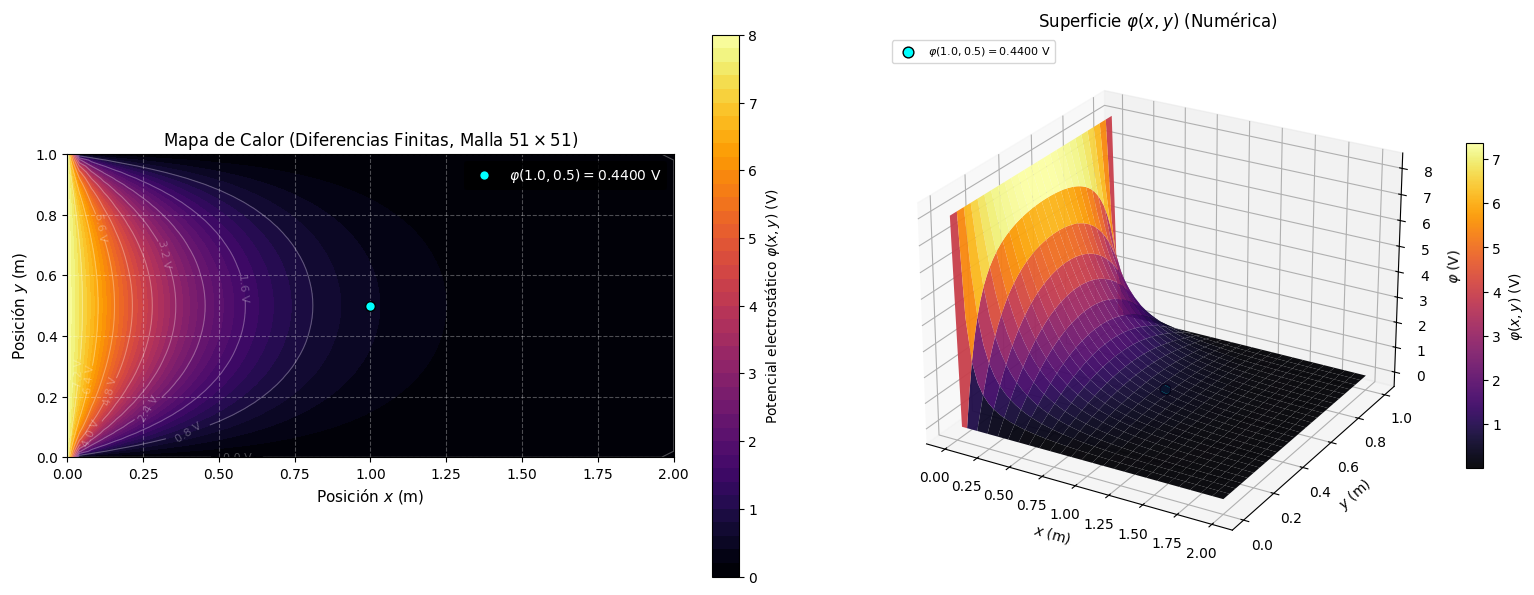

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from mpl_toolkits.mplot3d import Axes3D  # Necesario para gráficos 3D

# PARÁMETROS DEL PROBLEMA
a, b = 2.0, 1.0      # Dimensiones del rectángulo (2 x 1 m)
V1 = 8.0             # Potencial en la frontera izquierda (x=0)
Nx, Ny = 51, 51      # Número de puntos en la malla

# Creación de la malla bidimensional (Grid)
x = np.linspace(0, a, Nx)
y = np.linspace(0, b, Ny)
X, Y = np.meshgrid(x, y)

# 2. SOLUCIÓN NUMÉRICA (Diferencias Finitas)
dx = a / (Nx - 1)
dy = b / (Ny - 1)
nx_in, ny_in = Nx - 2, Ny - 2  # Solo calculamos los nodos interiores

# Matrices de segunda derivada 1D (Diagonales: 1, -2, 1)
D2x = sp.diags([1, -2, 1], [-1, 0, 1], shape=(nx_in, nx_in)) / dx**2
D2y = sp.diags([1, -2, 1], [-1, 0, 1], shape=(ny_in, ny_in)) / dy**2

# Matriz Laplaciana 2D (Producto de Kronecker)
Ix = sp.eye(nx_in)
Iy = sp.eye(ny_in)
L = sp.kron(Iy, D2x) + sp.kron(D2y, Ix)

# Vector de condiciones de frontera (RHS)
b_vec = np.zeros((ny_in, nx_in))
# La frontera izquierda afecta a la primera columna de nodos interiores (x=0)
b_vec[:, 0] -= V1 / dx**2
b_flat = b_vec.flatten()

# Resolver el sistema lineal L * phi_interior = b_flat
phi_in_flat = spla.spsolve(L, b_flat)
phi_in = phi_in_flat.reshape((ny_in, nx_in))

# Ensamblar la matriz completa sumando las fronteras (que valen 0 y V1)
phi_numerica = np.zeros((Ny, Nx))
phi_numerica[1:-1, 1:-1] = phi_in  # Insertar centro
phi_numerica[:, 0] = V1            # Condición de frontera izquierda (x=0)
# Las demás fronteras permanecen en 0 (derecha, inferior y superior)

# CÁLCULO DEL POTENCIAL EN EL PUNTO (1.0, 0.5)
idx_x_punto = np.argmin(np.abs(x - 1.0))
idx_y_punto = np.argmin(np.abs(y - 0.5))
x_p, y_p = x[idx_x_punto], y[idx_y_punto]
phi_punto_num = phi_numerica[idx_y_punto, idx_x_punto]

# GRAFICACIÓN: FIGURA CON DOS SUBPLOTS (contorno + superficie 3D)
fig = plt.figure(figsize=(16, 6))

# --- SUBPLOT 1: Mapa de calor (contourf) ---
ax1 = fig.add_subplot(1, 2, 1)

contour2 = ax1.contourf(X, Y, phi_numerica, levels=50, cmap='inferno')
cbar = fig.colorbar(contour2, ax=ax1, label=r'Potencial electrostático $\varphi(x,y)$ (V)')

lines = ax1.contour(X, Y, phi_numerica, levels=10, colors='white', alpha=0.3, linewidths=0.8)
ax1.clabel(lines, inline=True, fontsize=8, fmt='%.1f V')

ax1.plot(x_p, y_p, 'o', color='cyan', markersize=7, markeredgecolor='black',
         label=rf'$\varphi({x_p:.1f}, {y_p:.1f}) = {phi_punto_num:.4f}\text{{ V}}$')

ax1.set_title(rf'Mapa de Calor (Diferencias Finitas, Malla ${Nx} \times {Ny}$)', fontsize=12)
ax1.set_xlabel(r'Posición $x$ (m)', fontsize=11)
ax1.set_ylabel(r'Posición $y$ (m)', fontsize=11)
ax1.set_xlim(0, a)
ax1.set_ylim(0, b)
ax1.set_aspect('equal')
ax1.grid(True, linestyle='--', alpha=0.3, color='white')
ax1.legend(loc='upper right', framealpha=0.8, facecolor='black', edgecolor='none', labelcolor='white')

# --- SUBPLOT 2: Superficie 3D ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

surf = ax2.plot_surface(X, Y, phi_numerica, cmap='inferno',
                         linewidth=0, antialiased=True, alpha=0.95)

fig.colorbar(surf, ax=ax2, shrink=0.6, label=r'$\varphi(x,y)$ (V)')

# Marcar el punto especial también en la superficie
ax2.scatter(x_p, y_p, phi_punto_num, color='cyan', s=60, edgecolor='black',
            label=rf'$\varphi({x_p:.1f}, {y_p:.1f}) = {phi_punto_num:.4f}$ V')

ax2.set_title(r'Superficie $\varphi(x,y)$ (Numérica)', fontsize=12)
ax2.set_xlabel(r'$x$ (m)', fontsize=10)
ax2.set_ylabel(r'$y$ (m)', fontsize=10)
ax2.set_zlabel(r'$\varphi$ (V)', fontsize=10)
ax2.view_init(elev=25, azim=-60)  # Ángulo de vista (ajustable)
ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

**Gráfica 3: Perfil del error absoluto en y = b/2**

> **Análisis:** Este gráfico muestra el error absoluto
> $$|\varphi_{\text{analítica}} - \varphi_{\text{numérica}}|$$
> calculado a lo largo de la línea horizontal $y = b/2$, es decir, a media altura del rectángulo. En el interior del dominio el error es prácticamente despreciable, lo que confirma la concordancia entre la solución analítica obtenida por serie de Fourier truncada y la solución numérica por diferencias finitas.
>
> El error aumenta ligeramente cerca de la frontera izquierda $x = 0$, donde la condición de borde impone un salto abrupto entre el potencial $V_1$ y el potencial $0$ de las fronteras inferior y superior. Este comportamiento es esperado por el **fenómeno de Gibbs**: la serie truncada de Fourier introduce oscilaciones cerca de la discontinuidad, mientras que el método numérico suaviza localmente la transición. Cerca de la frontera derecha $x = a$, ambos métodos imponen potencial nulo, por lo que el error vuelve a ser prácticamente cero.

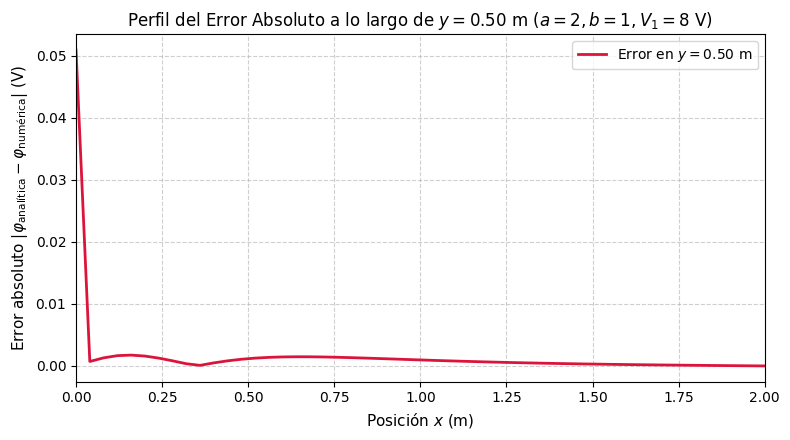

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# PARÁMETROS DEL PROBLEMA
a, b = 2.0, 1.0      # Dimensiones del rectángulo (2 x 1 m)
V1 = 8.0             # Potencial en la frontera izquierda (x=0)

# Usamos un número impar de puntos (51x51) para que el centro (1.0, 0.5) sea exacto en la malla
Nx, Ny = 51, 51

# Recrear vectores de posición
x = np.linspace(0, a, Nx)
y = np.linspace(0, b, Ny)

# ---------------------------------------------------------
# 3. CÁLCULO Y GRÁFICA DEL ERROR
# ---------------------------------------------------------

# 1. Matriz de error absoluto punto a punto |Analítica - Numérica|
error_absoluto = np.abs(phi_analitica - phi_numerica)

# 2. Tomar el corte transversal en el centro del dominio: y = b/2 (y = 0.5 m)
indice_y_medio = np.argmin(np.abs(y - b/2))
error_corte = error_absoluto[indice_y_medio, :]
y_real_corte = y[indice_y_medio]

# Gráfica 1D: Perfil del error en y = b/2
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(x, error_corte, color='crimson', linewidth=2, label=rf'Error en $y = {y_real_corte:.2f}\text{{ m}}$')
ax.set_xlabel(r'Posición $x$ (m)', fontsize=11)
ax.set_ylabel(r'Error absoluto $| \varphi_{\text{analítica}} - \varphi_{\text{numérica}} |$ (V)', fontsize=11)
ax.set_title(rf'Perfil del Error Absoluto a lo largo de $y = {y_real_corte:.2f}\text{{ m}}$ ($a=2, b=1, V_1=8\text{{ V}}$)', fontsize=12)
ax.set_xlim(0, a)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()
